# Assignment 3 – Parte 1: Visualización con Plotly

**Pregunta del Assignment 2 que seguimos usando:** ¿el Estado declara emergencia donde más llueve?

**Dataset:** `datos/dataset.csv`, que es la `tabla_final.csv` del Assignment 2 copiada sin cambios (opción B del enunciado).
Temporada: 1 de enero al 31 de mayo de 2022. Una fila por departamento (25).

**Fuentes de los datos (recolectados en el Assignment 2):**
- Lluvia: [Open-Meteo, Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api), lluvia diaria en la ciudad capital de cada departamento.
- Declaratorias de emergencia: decretos supremos de la PCM publicados en [gob.pe](https://www.gob.pe/busquedas?contenido=normas).

Los gráficos se muestran con el renderizador `plotly_mimetype+png`: en Jupyter o VS Code se ven interactivos, y la copia en PNG (generada con kaleido) permite verlos también en GitHub, que no ejecuta el JavaScript de Plotly.

In [ ]:
#%pip install "plotly>=5.24" kaleido // instalar si es que no se tiene

from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+png"
pio.renderers["png"].width = 950
pio.renderers["png"].height = 600

DATOS = Path("datos")
pd.set_option("display.width", 200)

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 9.7/9.7 MB 54.8 MB/s  0:00:00

   ---------------------------------------- 0/6 [simplejson]
   ------ --------------------------------- 1/6 [narwhals]
   ------ --------------------------------- 1/6 [narwhals]
   ------ --------------------------------- 1/6 [narwhals]
   ------ --------------------------------- 1/6 [narwhals]
   ------ --------------------------------- 1/6 [narwhals]
   ------ --------------------------------- 1/6 [narwhals]
   ------ --------------------------------- 1/6 [narwhals]
   -------------------- ------------------- 3/6 [plotly]
   -------------------- ------------------- 3/6 [plotly]
   -------------------- ------------------- 3/6 [plotly]
   -------------------- ------------------- 3/6 [plotly]
   -------------------- ------------------- 3/6 [plotly]
   -------------------- ------------------- 3/6 [plotly]
   -------------------- ----------------

## 1. Cargar el dataset

Se lee con `dtype={"ubigeo": str}` para que el código de departamento se quede como texto (`'01'` y no `1`), y con `encoding="utf-8-sig"` porque el archivo se guardó con esa codificación en el Assignment 2 (si no, el nombre de la primera columna aparece como `\ufeffubigeo`).

In [3]:
df = pd.read_csv(DATOS / "dataset.csv", dtype={"ubigeo": str}, encoding="utf-8-sig")

print("Dimensiones (filas, columnas):", df.shape)
print("Tipo de la columna ubigeo:", df["ubigeo"].dtype, "| primer valor:", repr(df.loc[0, "ubigeo"]))
df.head(5)

Dimensiones (filas, columnas): (25, 7)
Tipo de la columna ubigeo: object | primer valor: '01'


,ubigeo,departamento,capital,lluvia_total_mm,dias_lluvia_fuerte,declaratorias,prorrogas
0,01,Amazonas,Chachapoyas,436.5,1,1,0
1,02,Áncash,Huaraz,975.3,7,0,0
2,03,Apurímac,Abancay,711.8,2,0,0
3,04,Arequipa,Arequipa,189.9,0,0,0
4,05,Ayacucho,Ayacucho,485.1,0,1,0


In [3]:
df.dtypes

ubigeo                 object
departamento           object
capital                object
lluvia_total_mm       float64
dias_lluvia_fuerte      int64
declaratorias           int64
prorrogas               int64
dtype: object

## 2. Tema y columnas

**Tema:** comparar cuánto llovió en cada departamento durante la temporada de lluvias de 2022 con las declaratorias de emergencia por lluvias que dio el Estado, para ver si las emergencias se declararon donde más llovió.

**Columnas que se usan:**
- `departamento`: nombre del departamento (para etiquetas y `hover_name`).
- `lluvia_total_mm`: lluvia acumulada del 1 de enero al 31 de mayo de 2022 en la capital del departamento, en milímetros.
- `dias_lluvia_fuerte`: número de días con 20 mm o más de lluvia en esa capital.
- `declaratorias`: número de decretos de la PCM que declaran estado de emergencia por lluvias en el departamento (los ceros son departamentos sin declaratoria).

A partir de `declaratorias` se crea una columna de texto, `declaratoria`, con dos grupos: "Con declaratoria" y "Sin declaratoria".

In [4]:
df["declaratoria"] = df["declaratorias"].gt(0).map({True: "Con declaratoria", False: "Sin declaratoria"})
df["puesto_lluvia"] = df["lluvia_total_mm"].rank(ascending=False, method="min").astype(int)

COLORES = {"Con declaratoria": "#c0392b", "Sin declaratoria": "#8fa9bf"}
FUENTE = (
    "Fuente: Open-Meteo (lluvia diaria en la capital de cada departamento) y gob.pe "
    "(decretos supremos de la PCM), 1 ene – 31 may 2022. Elaboración propia."
)


def dar_formato(fig, titulo, subtitulo, alto=600):
    """Título-conclusión, subtítulo, fuente al pie y estilo común para todos los gráficos."""
    fig.update_layout(
        title=dict(text=f"<b>{titulo}</b><br><sup>{subtitulo}</sup>", x=0.01, xanchor="left"),
        template="plotly_white",
        height=alto,
        margin=dict(t=130, b=95, l=10, r=20),
        legend_title_text="",
        font=dict(size=12),
    )
    fig.add_annotation(
        text=FUENTE, showarrow=False, xref="paper", yref="paper",
        x=0, y=-0.16, xanchor="left", yanchor="top", font=dict(size=10, color="gray"),
    )
    return fig


print(df["declaratoria"].value_counts().to_string())

declaratoria
Sin declaratoria    22
Con declaratoria     3


## 3. Gráfico de barras: lluvia acumulada por departamento

Barras horizontales ordenadas de mayor a menor, con el valor escrito en cada barra y en rojo los departamentos con declaratoria. El título se arma con los datos: primero se comprueba la afirmación y luego se escribe.

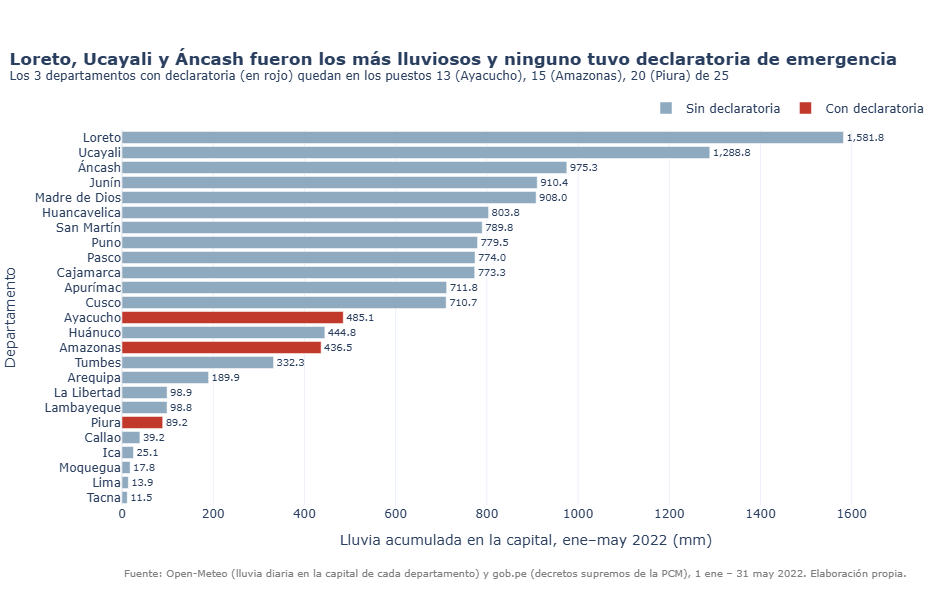

In [5]:
orden = df.sort_values("lluvia_total_mm", ascending=False)
top3 = orden.head(3)
con_decl = orden[orden["declaratorias"] > 0]

# La conclusión del título solo se escribe si los datos la confirman
assert (top3["declaratorias"] == 0).all(), "algún departamento del top 3 sí tiene declaratoria: cambiar el título"

titulo_barras = (
    f"{top3['departamento'].iloc[0]}, {top3['departamento'].iloc[1]} y {top3['departamento'].iloc[2]} "
    "fueron los más lluviosos y ninguno tuvo declaratoria de emergencia"
)
puestos = ", ".join(f"{r.puesto_lluvia} ({r.departamento})" for r in con_decl.itertuples())
subtitulo_barras = (
    f"Los {len(con_decl)} departamentos con declaratoria (en rojo) quedan en los puestos {puestos} de {len(df)}"
)

fig_barras = px.bar(
    orden, x="lluvia_total_mm", y="departamento", orientation="h",
    color="declaratoria", color_discrete_map=COLORES,
    text="lluvia_total_mm", hover_name="departamento",
    hover_data={"departamento": False, "capital": True, "dias_lluvia_fuerte": True, "declaratorias": True},
    labels={
        "lluvia_total_mm": "Lluvia acumulada en la capital, ene–may 2022 (mm)",
        "departamento": "Departamento",
        "declaratoria": "", "capital": "Capital",
        "dias_lluvia_fuerte": "Días con lluvia ≥ 20 mm", "declaratorias": "Declaratorias",
    },
)
fig_barras.update_traces(texttemplate="%{x:,.1f}", textposition="outside", cliponaxis=False)
fig_barras.update_yaxes(categoryorder="total ascending")
fig_barras.update_xaxes(range=[0, orden["lluvia_total_mm"].max() * 1.12])
dar_formato(fig_barras, titulo_barras, subtitulo_barras, alto=750)
fig_barras.update_layout(legend=dict(orientation="h", y=1.02, x=1, xanchor="right", yanchor="bottom"))
fig_barras.show()

## 4. Gráfico de dispersión: lluvia acumulada vs. días de lluvia fuerte

Dos variables continuas. Cada punto es un departamento (`hover_name` muestra su nombre al pasar el cursor) y el color indica si tuvo declaratoria. Las líneas punteadas marcan la mediana de cada eje.

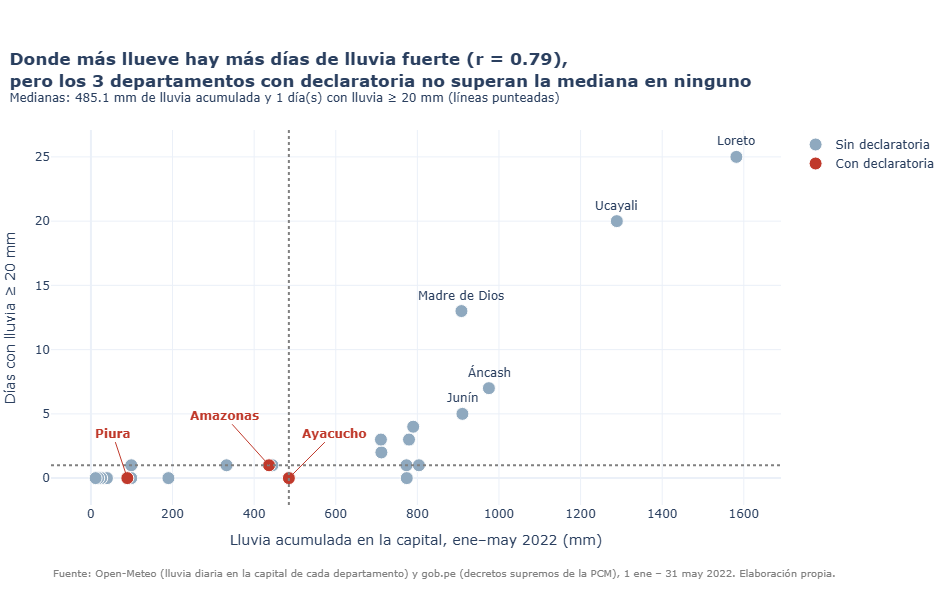

In [6]:
r = df["lluvia_total_mm"].corr(df["dias_lluvia_fuerte"])
med_lluvia = df["lluvia_total_mm"].median()
med_dias = df["dias_lluvia_fuerte"].median()

# Comprobaciones de lo que dice el título
assert r > 0.5, "la relación no es claramente positiva: cambiar el título"
assert (con_decl["lluvia_total_mm"] <= med_lluvia).all() and (con_decl["dias_lluvia_fuerte"] <= med_dias).all(), \
    "algún departamento con declaratoria supera una mediana: cambiar el título"

titulo_disp = (
    f"Donde más llueve hay más días de lluvia fuerte (r = {r:.2f}),<br>pero los {len(con_decl)} "
    "departamentos con declaratoria no superan la mediana en ninguno"
)
subtitulo_disp = (
    f"Medianas: {med_lluvia:,.1f} mm de lluvia acumulada y {med_dias:.0f} día(s) con lluvia ≥ 20 mm "
    "(líneas punteadas)"
)

fig_disp = px.scatter(
    df, x="lluvia_total_mm", y="dias_lluvia_fuerte",
    color="declaratoria", color_discrete_map=COLORES,
    hover_name="departamento",
    hover_data={"capital": True, "declaratorias": True, "declaratoria": False},
    category_orders={"declaratoria": ["Sin declaratoria", "Con declaratoria"]},  # los rojos se dibujan encima
    labels={
        "lluvia_total_mm": "Lluvia acumulada en la capital, ene–may 2022 (mm)",
        "dias_lluvia_fuerte": "Días con lluvia ≥ 20 mm",
        "declaratoria": "", "capital": "Capital", "declaratorias": "Declaratorias",
    },
)
fig_disp.update_traces(marker=dict(size=13, line=dict(width=1, color="white")))
# Etiquetas: los 3 con declaratoria (con flecha, porque están pegados a otros puntos) y los 5 más lluviosos
desfases = {"Amazonas": (-45, -50), "Ayacucho": (45, -45), "Piura": (-15, -45)}
for fila in con_decl.itertuples():
    ax, ay = desfases.get(fila.departamento, (0, -40))
    fig_disp.add_annotation(x=fila.lluvia_total_mm, y=fila.dias_lluvia_fuerte, text=f"<b>{fila.departamento}</b>",
                            ax=ax, ay=ay, arrowcolor=COLORES["Con declaratoria"],
                            font=dict(color=COLORES["Con declaratoria"]))
for fila in orden.head(5).itertuples():
    fig_disp.add_annotation(x=fila.lluvia_total_mm, y=fila.dias_lluvia_fuerte, text=fila.departamento,
                            showarrow=False, yshift=16)
fig_disp.add_vline(x=med_lluvia, line_dash="dot", line_color="gray")
fig_disp.add_hline(y=med_dias, line_dash="dot", line_color="gray")
dar_formato(fig_disp, titulo_disp, subtitulo_disp)
fig_disp.show()

## 5. Tercer gráfico: diagrama de cajas por grupo

Compara la distribución de la lluvia acumulada entre los departamentos con y sin declaratoria. Se muestran todos los puntos porque el grupo con declaratoria es muy chico.

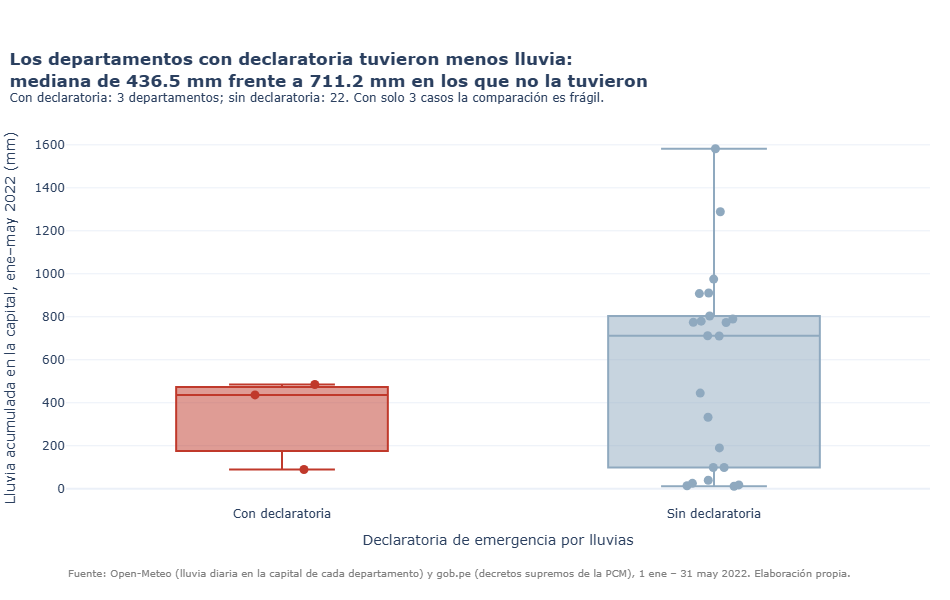

In [7]:
medianas = df.groupby("declaratoria")["lluvia_total_mm"].median()
n_grupo = df["declaratoria"].value_counts()
m_con, m_sin = medianas["Con declaratoria"], medianas["Sin declaratoria"]

assert m_con < m_sin, "la mediana con declaratoria no es menor: cambiar el título"

titulo_cajas = (
    f"Los departamentos con declaratoria tuvieron menos lluvia:<br>mediana de {m_con:,.1f} mm "
    f"frente a {m_sin:,.1f} mm en los que no la tuvieron"
)
subtitulo_cajas = (
    f"Con declaratoria: {n_grupo['Con declaratoria']} departamentos; sin declaratoria: "
    f"{n_grupo['Sin declaratoria']}. Con solo {n_grupo['Con declaratoria']} casos la comparación es frágil."
)

fig_cajas = px.box(
    df, x="declaratoria", y="lluvia_total_mm",
    color="declaratoria", color_discrete_map=COLORES,
    points="all", hover_name="departamento",
    category_orders={"declaratoria": ["Con declaratoria", "Sin declaratoria"]},
    labels={
        "lluvia_total_mm": "Lluvia acumulada en la capital, ene–may 2022 (mm)",
        "declaratoria": "Declaratoria de emergencia por lluvias",
    },
)
fig_cajas.update_traces(marker=dict(size=9), pointpos=0, jitter=0.4)
dar_formato(fig_cajas, titulo_cajas, subtitulo_cajas)
fig_cajas.update_layout(showlegend=False)
fig_cajas.show()

## 6. Verificación rápida: ¿los extremos de la tabla son los mismos que dibujan los gráficos?

Se leen los valores **desde las figuras** (`fig.data`, lo que Plotly realmente dibuja) y se comparan con el máximo y el mínimo calculados directamente en la tabla.

In [8]:
def puntos_de(fig, eje_valor, eje_nombre=None):
    """Junta en una tabla los puntos de todas las trazas de una figura."""
    filas = []
    for traza in fig.data:
        valores = getattr(traza, eje_valor)
        nombres = getattr(traza, eje_nombre) if eje_nombre else traza.hovertext
        filas += list(zip(nombres, valores))
    return pd.DataFrame(filas, columns=["departamento", "valor"])


fila_max = df.loc[df["lluvia_total_mm"].idxmax()]
fila_min = df.loc[df["lluvia_total_mm"].idxmin()]
fila_max_dias = df.loc[df["dias_lluvia_fuerte"].idxmax()]

pb = puntos_de(fig_barras, "x", "y")
pd_ = puntos_de(fig_disp, "y")
pc = puntos_de(fig_cajas, "y")

chequeo = pd.DataFrame([
    ["Barras", "máximo de lluvia", f"{fila_max.departamento} ({fila_max.lluvia_total_mm})",
     f"{pb.loc[pb.valor.idxmax(), 'departamento']} ({pb.valor.max()})"],
    ["Barras", "mínimo de lluvia", f"{fila_min.departamento} ({fila_min.lluvia_total_mm})",
     f"{pb.loc[pb.valor.idxmin(), 'departamento']} ({pb.valor.min()})"],
    ["Dispersión", "máximo de días ≥ 20 mm", f"{fila_max_dias.departamento} ({fila_max_dias.dias_lluvia_fuerte})",
     f"{pd_.loc[pd_.valor.idxmax(), 'departamento']} ({pd_.valor.max()})"],
    ["Cajas", "máximo de lluvia", f"{fila_max.departamento} ({fila_max.lluvia_total_mm})",
     f"{pc.loc[pc.valor.idxmax(), 'departamento']} ({pc.valor.max()})"],
    ["Cajas", "mínimo de lluvia", f"{fila_min.departamento} ({fila_min.lluvia_total_mm})",
     f"{pc.loc[pc.valor.idxmin(), 'departamento']} ({pc.valor.min()})"],
], columns=["gráfico", "dato", "en la tabla", "en el gráfico"])
chequeo["coincide"] = chequeo["en la tabla"] == chequeo["en el gráfico"]

assert chequeo["coincide"].all(), "algún extremo del gráfico no coincide con la tabla"
assert len(pb) == len(pd_) == len(pc) == len(df), "algún gráfico no tiene los 25 departamentos"
print("Puntos dibujados por gráfico:", len(pb), len(pd_), len(pc), "| filas de la tabla:", len(df))
chequeo

Puntos dibujados por gráfico: 25 25 25 | filas de la tabla: 25


,gráfico,dato,en la tabla,en el gráfico,coincide
0,Barras,máximo de lluvia,Loreto (1581.8),Loreto (1581.8),True
1,Barras,mínimo de lluvia,Tacna (11.5),Tacna (11.5),True
2,Dispersión,máximo de días ≥ 20 mm,Loreto (25),Loreto (25),True
3,Cajas,máximo de lluvia,Loreto (1581.8),Loreto (1581.8),True
4,Cajas,mínimo de lluvia,Tacna (11.5),Tacna (11.5),True


In [9]:
# Los 3 más altos y los 3 más bajos, para compararlos a ojo con la parte de arriba y de abajo del gráfico de barras
pd.concat([orden.head(3), orden.tail(3)])[["departamento", "lluvia_total_mm", "dias_lluvia_fuerte", "declaratorias"]]

,departamento,lluvia_total_mm,dias_lluvia_fuerte,declaratorias
15,Loreto,1581.8,25,0
24,Ucayali,1288.8,20,0
1,Áncash,975.3,7,0
17,Moquegua,17.8,0,0
14,Lima,13.9,0,0
22,Tacna,11.5,0,0


## 7. Exportar un gráfico a HTML

Se exporta el gráfico de barras. Con `include_plotlyjs="cdn"` el archivo pesa unos KB en lugar de varios MB (la librería de Plotly se carga desde internet al abrirlo).

In [10]:
fig_barras.write_html("grafico.html", include_plotlyjs="cdn")
print("Guardado: grafico.html |", round(Path("grafico.html").stat().st_size / 1024, 1), "KB")

Guardado: grafico.html | 11.3 KB


## 8. Lo que muestran los gráficos

Los números de esta sección salen de las celdas anteriores.

- **Barras:** Loreto (1,581.8 mm), Ucayali (1,288.8 mm) y Áncash (975.3 mm) fueron los departamentos con más lluvia acumulada y ninguno tuvo declaratoria. Los 3 con declaratoria están en los puestos 13 (Ayacucho), 15 (Amazonas) y 20 (Piura) de 25.
- **Dispersión:** las dos medidas de lluvia van juntas (r = 0.79), así que el resultado no depende de usar la lluvia total o los días de lluvia fuerte: los departamentos con declaratoria no superan la mediana en ninguna de las dos.
- **Cajas:** la mediana de lluvia de los departamentos con declaratoria (436.5 mm) es menor que la de los que no la tuvieron (711.2 mm).
- **Cautela:** en la temporada se encontró un solo decreto de lluvias (DS 032-2022-PCM), que cubre a 3 departamentos, y la lluvia es la de una sola ciudad por departamento. Los gráficos describen estos datos; no prueban que el Estado nunca declare emergencia donde más llueve.